<a href="https://colab.research.google.com/github/janhvim003-source/Invoice-data-extraction/blob/main/Data_Ext.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving batch1-0001.jpg to batch1-0001.jpg
Saving batch1-0002.jpg to batch1-0002.jpg
Saving batch1-0003.jpg to batch1-0003.jpg
Saving batch1-0004.jpg to batch1-0004.jpg
Saving batch1-0005.jpg to batch1-0005.jpg
Saving batch1-0006.jpg to batch1-0006.jpg
Saving batch1-0007.jpg to batch1-0007.jpg
Saving batch1-0008.jpg to batch1-0008.jpg
Saving batch1-0009.jpg to batch1-0009.jpg
Saving batch1-0010.jpg to batch1-0010.jpg
Saving batch1-0011.jpg to batch1-0011.jpg
Saving batch1-0012.jpg to batch1-0012.jpg
Saving batch1-0013.jpg to batch1-0013.jpg
Saving batch1-0014.jpg to batch1-0014.jpg
Saving batch1-0015.jpg to batch1-0015.jpg
Saving batch1-0016.jpg to batch1-0016.jpg
Saving batch1-0017.jpg to batch1-0017.jpg
Saving batch1-0018.jpg to batch1-0018.jpg
Saving batch1-0019.jpg to batch1-0019.jpg
Saving batch1-0020.jpg to batch1-0020.jpg
Saving batch1-0021.jpg to batch1-0021.jpg
Saving batch1-0022.jpg to batch1-0022.jpg
Saving batch1-0023.jpg to batch1-0023.jpg
Saving batch1-0024.jpg to batch1-0

In [ ]:
# List files in the current directory to find your uploaded image filenames
!ls -F

batch1-0001.jpg  batch1-0126.jpg  batch1-0251.jpg  batch1-0376.jpg
batch1-0002.jpg  batch1-0127.jpg  batch1-0252.jpg  batch1-0377.jpg
batch1-0003.jpg  batch1-0128.jpg  batch1-0253.jpg  batch1-0378.jpg
batch1-0004.jpg  batch1-0129.jpg  batch1-0254.jpg  batch1-0379.jpg
batch1-0005.jpg  batch1-0130.jpg  batch1-0255.jpg  batch1-0380.jpg
batch1-0006.jpg  batch1-0131.jpg  batch1-0256.jpg  batch1-0381.jpg
batch1-0007.jpg  batch1-0132.jpg  batch1-0257.jpg  batch1-0382.jpg
batch1-0008.jpg  batch1-0133.jpg  batch1-0258.jpg  batch1-0383.jpg
batch1-0009.jpg  batch1-0134.jpg  batch1-0259.jpg  batch1-0384.jpg
batch1-0010.jpg  batch1-0135.jpg  batch1-0260.jpg  batch1-0385.jpg
batch1-0011.jpg  batch1-0136.jpg  batch1-0261.jpg  batch1-0386.jpg
batch1-0012.jpg  batch1-0137.jpg  batch1-0262.jpg  batch1-0387.jpg
batch1-0013.jpg  batch1-0138.jpg  batch1-0263.jpg  batch1-0388.jpg
batch1-0014.jpg  batch1-0139.jpg  batch1-0264.jpg  batch1-0389.jpg
batch1-0015.jpg  batch1-0140.jpg  batch1-0265.jpg  batch1-0390

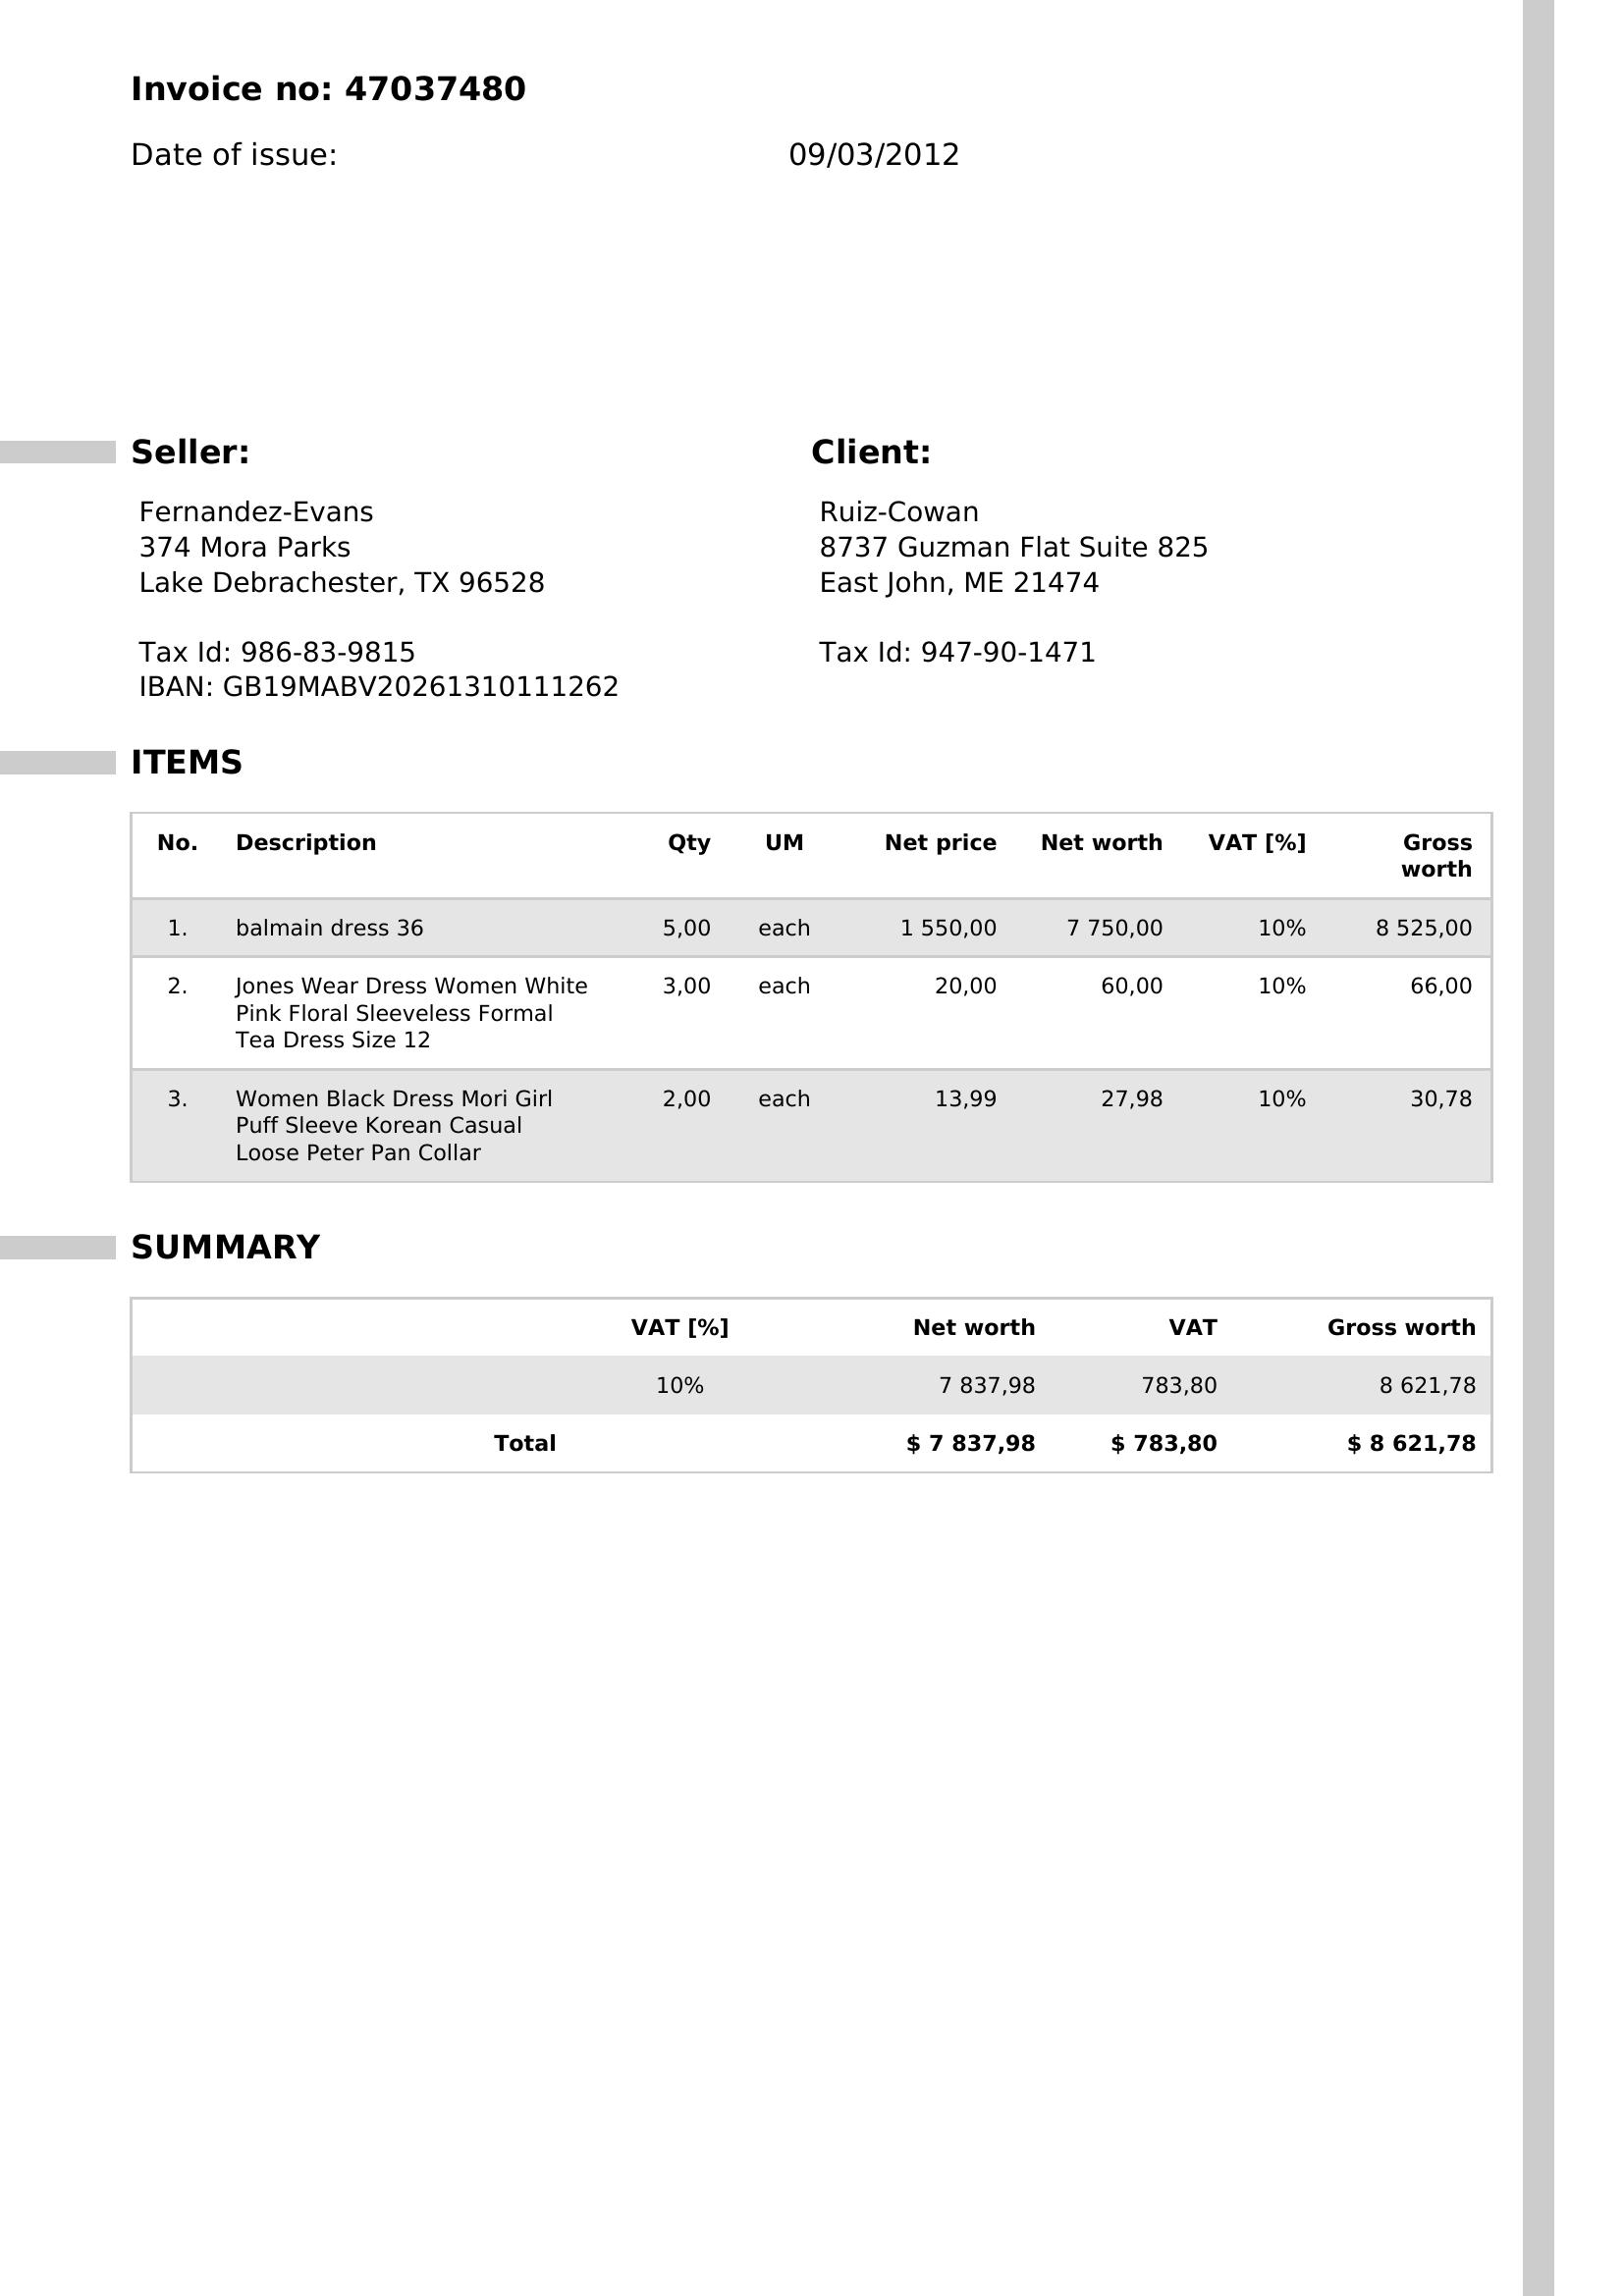

In [ ]:
from PIL import Image
from IPython.display import display

# Replace 'your_image_file.jpg' with the actual filename of one of your uploaded images
image_filename = 'batch1-0123.jpg'

try:
    img = Image.open(image_filename)
    display(img)
except FileNotFoundError:
    print(f"Error: The file '{image_filename}' was not found. Please check the filename.")
except Exception as e:
    print(f"An error occurred while opening or displaying the image: {e}")

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from skimage.filters import threshold_local

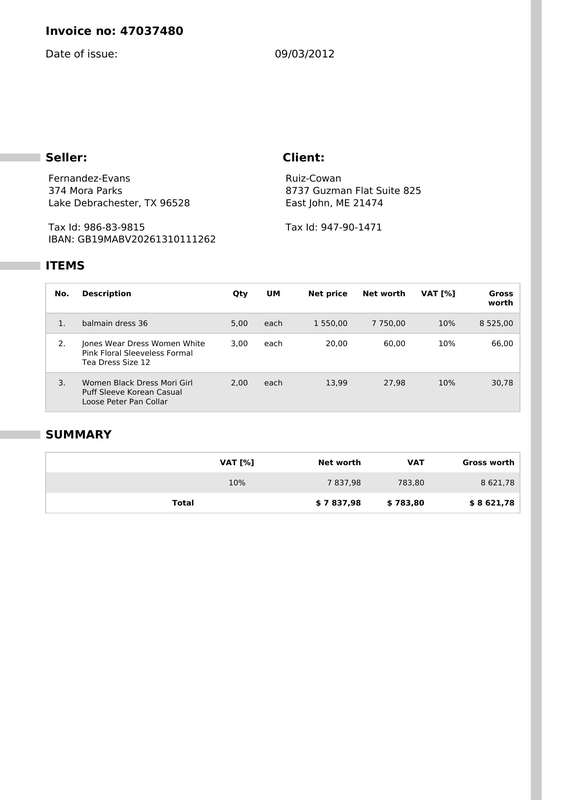

In [ ]:
import os
from PIL import Image

# Using the image_filename variable defined in a previous cell
file_name = image_filename # 'batch1-0123.jpg'
img = Image.open(file_name)
img.thumbnail((800,800), Image.LANCZOS)
img

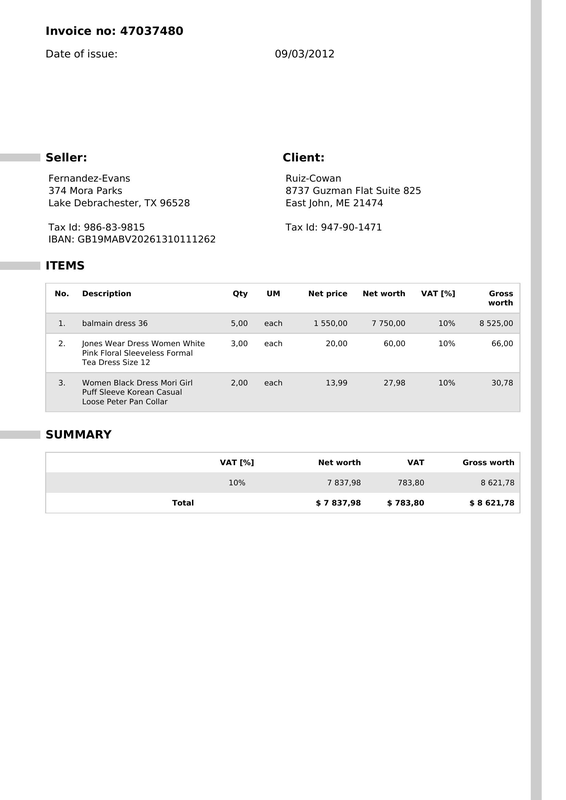

In [ ]:
# Convert the image to grayscale and display it
img_grayscale = img.convert('L')
display(img_grayscale)

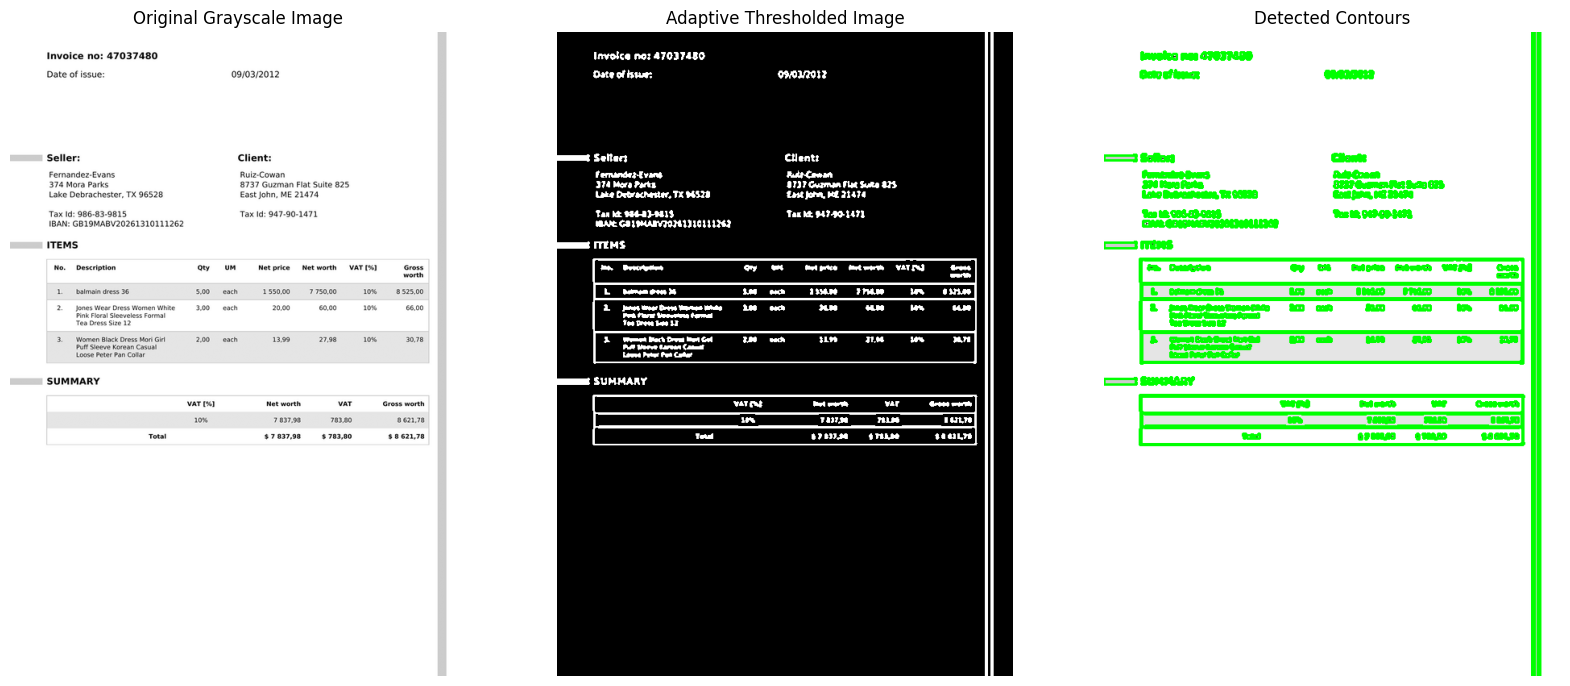

In [ ]:
# Convert PIL image to OpenCV format (NumPy array)
image_np = np.array(img_grayscale)

# Apply Gaussian blur to reduce noise and help with contour detection
blurred = cv2.GaussianBlur(image_np, (5, 5), 0)

# Apply adaptive thresholding
# This method is good for documents with varying lighting conditions
thresh = cv2.adaptiveThreshold(
    blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2
)

# Find contours in the thresholded image
contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

# Create a blank image to draw contours on, or draw on a copy of the original grayscale
# For visualization, let's draw on a color version of the grayscale for better contrast
contour_image = cv2.cvtColor(image_np, cv2.COLOR_GRAY2BGR)

# Draw all found contours in green (0, 255, 0) with a thickness of 2
cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 2)

# Display the original grayscale, thresholded, and contour images side-by-side
plt.figure(figsize=(20, 10))

plt.subplot(1, 3, 1)
plt.imshow(image_np, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(thresh, cmap='gray')
plt.title('Adaptive Thresholded Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
plt.title('Detected Contours')
plt.axis('off')

plt.show()

### Cropping Contours
Now that the contours are detected, let's crop each significant contour into a separate image. This can help isolate individual elements of the document for further processing.

Found 261 contours. Filtering and cropping...
Displaying cropped contour 1 (Area: 61342, Aspect Ratio: 3.64)


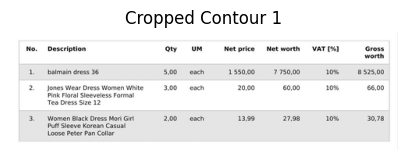

Successfully cropped and displayed 1 significant regions.


In [ ]:
cropped_images = []

# Sort contours by area in descending order to process larger contours first
contours_sorted = sorted(contours, key=cv2.contourArea, reverse=True)

print(f"Found {len(contours_sorted)} contours. Filtering and cropping...")

# Iterate through sorted contours
for i, contour in enumerate(contours_sorted):
    # Approximate the contour to a polygon
    peri = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.02 * peri, True)

    # Get the bounding box for the contour
    x, y, w, h = cv2.boundingRect(approx)

    # Calculate aspect ratio (width / height)
    aspect_ratio = w / float(h)

    # Only consider contours that are reasonably sized (e.g., area > 1000 pixels),
    # have a certain number of vertices to avoid noise, AND have a reasonable aspect ratio
    # Aspect ratio check (e.g., between 0.2 and 5.0 for typical document elements)
    if cv2.contourArea(contour) > 1000 and len(approx) >= 4 and 0.2 < aspect_ratio < 5.0:

        # Add a small padding to the bounding box to ensure the entire contour is captured
        padding = 10
        x_padded = max(0, x - padding)
        y_padded = max(0, y - padding)
        w_padded = min(image_np.shape[1] - x_padded, w + 2 * padding)
        h_padded = min(image_np.shape[0] - y_padded, h + 2 * padding)

        # Crop the original grayscale image using the bounding box
        cropped_region = image_np[y_padded : y_padded + h_padded, x_padded : x_padded + w_padded]

        # Display each cropped image (optional, can be commented out for many images)
        print(f"Displaying cropped contour {i+1} (Area: {cv2.contourArea(contour):.0f}, Aspect Ratio: {aspect_ratio:.2f})")
        plt.figure(figsize=(5, 5))
        plt.imshow(cropped_region, cmap='gray')
        plt.title(f'Cropped Contour {i+1}')
        plt.axis('off')
        plt.show()

        cropped_images.append(cropped_region)

print(f"Successfully cropped and displayed {len(cropped_images)} significant regions.")


Saved cropped document region to 'cropped_document_region.png'


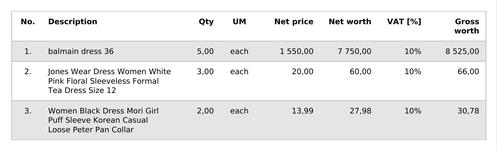

In [ ]:
# Save the last cropped region to a file
# Assuming `cropped_region` holds the last successfully cropped image from the previous cell's loop
# If you want to save all of them, you would iterate through `cropped_images`

if len(cropped_images) > 0:
    # Get the last cropped image
    final_cropped_image = cropped_images[-1]
    output_filename = 'cropped_document_region.png'
    cv2.imwrite(output_filename, final_cropped_image)
    print(f"Saved cropped document region to '{output_filename}'")
    # Display the saved image to confirm
    display(Image.open(output_filename))
else:
    print("No cropped images were found to save.")

### Text Extraction using OCR
 we have a cropped image of the document, we can use Optical Character Recognition (OCR) to extract the text from it. We'll use `pytesseract`, a Python wrapper for Google's Tesseract-OCR Engine.

In [ ]:
# Install Tesseract-OCR and pytesseract
!sudo apt install tesseract-ocr
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
import pytesseract
from PIL import Image

# Assuming 'final_cropped_image' holds the NumPy array of the cropped image
# If you have saved it, you can load it:
# final_cropped_image = cv2.imread('cropped_document_region.png')
# Make sure it's in a suitable format for pytesseract, usually PIL Image or OpenCV NumPy array

# Convert NumPy array to PIL Image for pytesseract
image_for_ocr = Image.fromarray(final_cropped_image)

# Use pytesseract to extract text
extracted_text = pytesseract.image_to_string(image_for_ocr)

print("\n--- Extracted Text ---")
print(extracted_text)
print("----------------------")


--- Extracted Text ---
Description

Jones Wear Dress women White

‘Women sack ress Mon Git
{bore Fever Pan Color

oy

500

200

um

1398

2798

var om

1k

‘ross

3078

----------------------


### Batch Processing Multiple Images
 we have a working pipeline for a single image, i've created a function to process all images in the directory and extract text from them.

In [ ]:
import os
from PIL import Image
import cv2
import numpy as np
import pytesseract

def process_image_for_text(image_path):
    try:
        # 1. Load Image and convert to grayscale
        img_pil = Image.open(image_path)
        img_pil.thumbnail((800,800), Image.LANCZOS) # Resize for faster processing
        img_grayscale_pil = img_pil.convert('L')
        image_np = np.array(img_grayscale_pil)

        # 2. Apply Gaussian blur
        blurred = cv2.GaussianBlur(image_np, (5, 5), 0)

        # 3. Apply adaptive thresholding
        thresh = cv2.adaptiveThreshold(
            blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2
        )

        # 4. Find contours
        contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
        contours_sorted = sorted(contours, key=cv2.contourArea, reverse=True)

        final_cropped_image = None
        # 5. Filter and crop the most significant contour based on area and aspect ratio
        for contour in contours_sorted:
            peri = cv2.arcLength(contour, True)
            approx = cv2.approxPolyDP(contour, 0.02 * peri, True)

            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = w / float(h)

            if cv2.contourArea(contour) > 1000 and len(approx) >= 4 and 0.2 < aspect_ratio < 5.0:
                padding = 10
                x_padded = max(0, x - padding)
                y_padded = max(0, y - padding)
                w_padded = min(image_np.shape[1] - x_padded, w + 2 * padding)
                h_padded = min(image_np.shape[0] - y_padded, h + 2 * padding)

                final_cropped_image = image_np[y_padded : y_padded + h_padded, x_padded : x_padded + w_padded]
                break # Take the first significant contour found

        if final_cropped_image is not None:
            # 6. Perform OCR on the cropped image
            image_for_ocr = Image.fromarray(final_cropped_image)
            extracted_text = pytesseract.image_to_string(image_for_ocr)
            return extracted_text.strip()
        else:
            return "No significant region found for OCR."

    except Exception as e:
        return f"Error processing {image_path}: {e}"

# Get a list of all image files in the current directory
image_files = [f for f in os.listdir('.') if f.endswith(('.jpg', '.jpeg', '.png', '.gif'))]

# Dictionary to store results
all_extracted_texts = {}

print(f"Processing {len(image_files)} images...")

for i, img_file in enumerate(image_files):
    print(f"[{i+1}/{len(image_files)}] Processing {img_file}...")
    extracted_content = process_image_for_text(img_file)
    all_extracted_texts[img_file] = extracted_content

print("\n--- Batch Processing Results ---")
for filename, text in all_extracted_texts.items():
    print(f"\nFilename: {filename}")
    print(f"Extracted Text:\n{text[:500]}...") # Print first 500 characters of extracted text
print("--------------------------------")

Streaming output truncated to the last 5000 lines.
hoy Steks 615 Gores "1978

 

200

um

155.00

Net worth

310.00

var om

ioe

‘ross
worn

3A00...

Filename: batch1-0384.jpg
Extracted Text:
Description

‘ell opti sr Oestop
Computer Window 0 868

Fast Dal Optiplex Deitop PC
Computer bua Core 30h
‘8088 win 10 Pow

Desktop Computer Tower #c

10 Computer stk ntl 28350,
uaa owe

set een a
ae

400

200

um

21700

7.00

Net worth

 

“3400

23950,00

var om

1%

10%

‘ross
worn

710

4345.00...

Filename: batch1-0091.jpg
Extracted Text:
Description oy

Alcohoimete coh Meter 300
‘Wine 02005 s thermometer
Set mar tools Vinage Tester

Wagner vineyards uncorknew 2.00

Yorkin Ges

sole Cnr vee ope “

1009s Heat Svink Capsules
vel wina Bota Cope

Wine Opener“ €H1035 Bond

‘Stiles Steet Reusable 300
‘Vacuum Sealed Champagne
tne bat Sopp op

 

um

Net worth

var om

‘ross
worn...

Filename: batch1-0161.jpg
Extracted Text:
Description

 

et More Living Room Center
‘able Top Yeltsh Seo Shall
Inla

In [ ]:
import pandas as pd

# Convert the dictionary to a pandas DataFrame
df_extracted_texts = pd.DataFrame(all_extracted_texts.items(), columns=['filename', 'extracted_text'])

# Save the DataFrame to a CSV file
output_csv_filename = 'extracted_texts.csv'
df_extracted_texts.to_csv(output_csv_filename, index=False)

print(f"Extracted texts saved to '{output_csv_filename}'")

# Display the first few rows of the DataFrame to confirm
print("\n--- First 5 rows of the exported CSV ---")
display(df_extracted_texts.head())

Extracted texts saved to 'extracted_texts.csv'

--- First 5 rows of the exported CSV ---


,filename,extracted_text
0,batch1-0425.jpg,Description\n\n‘OC Kids Turbo Skate Shoe (ue\n...
1,batch1-0070.jpg,Description\n\n1685: Handwoven Nghon\naim ot a...
2,batch1-0453.jpg,Description\n\nCarpe que Hand Knotted.\n‘Sttav...
3,batch1-0059.jpg,Description\n\n‘Game unde 25008 Black\n\n \n\n...
4,batch1-0308.jpg,Description\n\n“LONG 46 Handmade Carpet\nting ...


In [ ]:
import pandas as pd

# Load the CSV file into a DataFrame
df_analysis = pd.read_csv('extracted_texts.csv')

# Check for missing values in the 'extracted_text' column
missing_values_count = df_analysis['extracted_text'].isnull().sum()

print(f"Number of missing values in 'extracted_text' column: {missing_values_count}")

# Display rows with missing values (if any)
if missing_values_count > 0:
    print("\nRows with missing 'extracted_text' values:")
    display(df_analysis[df_analysis['extracted_text'].isnull()])
else:
    print("No missing values found in the 'extracted_text' column.")

Number of missing values in 'extracted_text' column: 0
No missing values found in the 'extracted_text' column.


In [ ]:
import re

def parse_extracted_text(text):
    data = {
        'Description': '',
        'Qty': None,
        'UM': None,
        'Net worth': None,
        'var om': None,
        'ross worn': None
    }

    if not text:
        return data

    # Split the text into lines
    lines = text.split('\n')

    # Regex patterns for key-value pairs. Using regex to capture descriptions
    # and numerical values for other fields.
    # Description is usually the first non-empty line or multiple lines until a number starts.
    description_lines = []
    in_description = True
    for line in lines:
        line = line.strip()
        if not line:
            continue

        # Check if the line starts with a typical quantity/price pattern
        if re.match(r'^\d+(\.\d+)?\s*(?:each|um|Net worth|var om|ross worn)', line, re.IGNORECASE):
            in_description = False

        if in_description:
            # Try to capture description lines until numerical data starts
            if line and not re.search(r'\d+\s*(?:each|um)', line):
                description_lines.append(line)
            else:
                in_description = False
                # This line might contain a description and then numbers, or just numbers. Process it later.

    data['Description'] = ' '.join(description_lines).replace('Description', '').strip()

    # General pattern for 'KEY Value' where Value can be numerical
    qty_match = re.search(r'(\d+)\s*(?:each|qty|quantity)', text, re.IGNORECASE)
    if qty_match: data['Qty'] = int(qty_match.group(1))

    um_match = re.search(r'um\s*([\d,\.]+)', text, re.IGNORECASE)
    if um_match: data['UM'] = float(um_match.group(1).replace(',', ''))

    net_worth_match = re.search(r'Net worth\s*([\d,\.]+)', text, re.IGNORECASE)
    if net_worth_match: data['Net worth'] = float(net_worth_match.group(1).replace(',', ''))

    var_om_match = re.search(r'var om\s*([\d,\.]+)', text, re.IGNORECASE)
    if var_om_match: data['var om'] = float(var_om_match.group(1).replace(',', ''))

    ross_worn_match = re.search(r'ross worn\s*([\d,\.]+)', text, re.IGNORECASE)
    if ross_worn_match: data['ross worn'] = float(ross_worn_match.group(1).replace(',', ''))

    return data

# Apply the parsing function to the 'extracted_text' column
parsed_data = df_analysis['extracted_text'].apply(parse_extracted_text)

# Convert the list of dictionaries to a DataFrame and join it with the original DataFrame
df_parsed = pd.DataFrame(list(parsed_data))
df_analysis = pd.concat([df_analysis, df_parsed], axis=1)

print("DataFrame after extracting structured text:")
display(df_analysis.head())

DataFrame after extracting structured text:


,filename,extracted_text,Description,Qty,UM,Net worth,var om,ross worn
0,batch1-0425.jpg,Description\n\n‘OC Kids Turbo Skate Shoe (ue\n...,‘OC Kids Turbo Skate Shoe (ue ‘ig Kd) Col WHIT...,NaN,NaN,11556.0,NaN,None
1,batch1-0070.jpg,Description\n\n1685: Handwoven Nghon\naim ot a...,1685: Handwoven Nghon aim ot ares og Kaen Tos ...,NaN,NaN,19756.0,1.0,None
2,batch1-0453.jpg,Description\n\nCarpe que Hand Knotted.\n‘Sttav...,Carpe que Hand Knotted. ‘Sttaveo Runs 0678 Kos...,NaN,2.0,NaN,1.0,None
3,batch1-0059.jpg,Description\n\n‘Game unde 25008 Black\n\n \n\n...,‘Game unde 25008 Black Bie CONSOLE ONLY No Cho...,NaN,NaN,NaN,NaN,None
4,batch1-0308.jpg,Description\n\n“LONG 46 Handmade Carpet\nting ...,“LONG 46 Handmade Carpet ting Sene Hand Kroes ...,NaN,1550.0,550.0,1.0,None


Now that we have extracted the product descriptions and numeric values, we can filter the DataFrame.  filtering for items with 'Dress' in their description, or a 'Net worth' greater than a certain value.

In [ ]:
# Example 1: Filter for rows where 'Description' contains 'Dress'
dress_items = df_analysis[df_analysis['Description'].str.contains('Dress', case=False, na=False)]

print("\nItems with 'Dress' in description:")
display(dress_items[['filename', 'Description', 'Net worth']].head())

# Example 2: Filter for rows where 'Net worth' is greater than 1000 (adjust as needed)
high_value_items = df_analysis[df_analysis['Net worth'].notna() & (df_analysis['Net worth'] > 1000)]

print("\nItems with 'Net worth' greater than 1000:")
display(high_value_items[['filename', 'Description', 'Net worth']].head())


Items with 'Dress' in description:


,filename,Description,Net worth
12,cropped_document_region.png,Jones Wear Dress women White ‘Women sack ress ...,NaN
39,batch1-0179.jpg,tack Paty DRESS WT ‘eos angeles ress Madam Cou...,20800.0
46,batch1-0264.jpg,"Black Stipe US clr Dress, ‘ono Embrodered Fest...",2990.0
47,batch1-0327.jpg,ress Oke Dane von Furstenberg Wrap ‘curFono & ...,NaN
66,batch1-0102.jpg,Liza Byra ress Sa Coa ‘Green egaion Pit Shor G...,60.0



Items with 'Net worth' greater than 1000:


,filename,Description,Net worth
0,batch1-0425.jpg,‘OC Kids Turbo Skate Shoe (ue ‘ig Kd) Col WHIT...,11556.0
1,batch1-0070.jpg,1685: Handwoven Nghon aim ot ares og Kaen Tos ...,19756.0
6,batch1-0120.jpg,20 Core Gaming Computer Desktop Pe Toner 1 166...,114858.0
7,batch1-0495.jpg,{60 nes Marble inning Table ‘opinly Wore Lawn ...,723625.0
10,batch1-0138.jpg,(se16i30) “4 es Tale Feet Durable High ‘aly St...,3600.0


### Visualize 'Net worth' Distribution

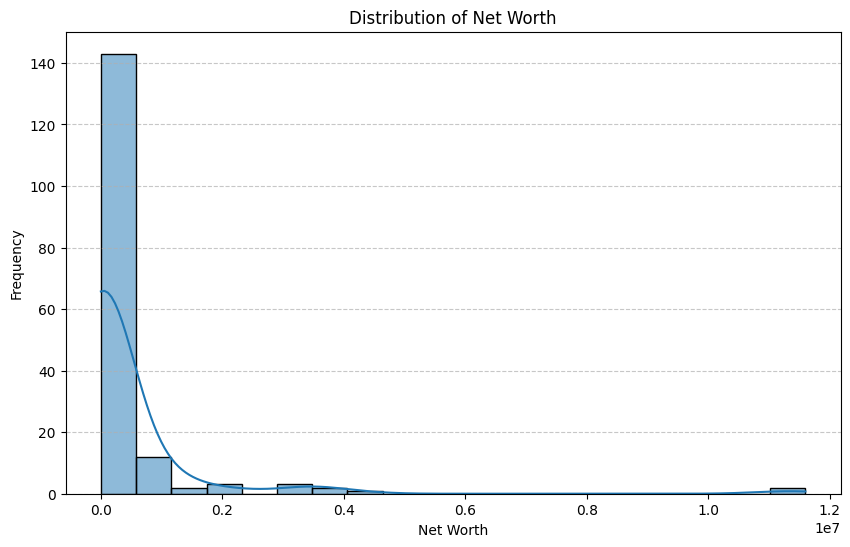

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop rows where 'Net worth' is NaN for visualization purposes
# Or, fill NaN values if that makes sense for the analysis
# For a histogram, dropping NaNs is usually appropriate.
df_net_worth = df_analysis.dropna(subset=['Net worth'])

plt.figure(figsize=(10, 6))
sns.histplot(df_net_worth['Net worth'], bins=20, kde=True)
plt.title('Distribution of Net Worth')
plt.xlabel('Net Worth')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Top 10 Items by 'Net worth'

Let's identify the items with the highest 'Net worth' values in our dataset.

In [ ]:
# Sort the DataFrame by 'Net worth' in descending order and get the top 10
top_10_net_worth = df_analysis.dropna(subset=['Net worth']).sort_values(by='Net worth', ascending=False).head(10)

print("\nTop 10 items with the highest 'Net worth':")
display(top_10_net_worth[['filename', 'Description', 'Net worth']])


Top 10 items with the highest 'Net worth':


,filename,Description,Net worth
60,batch1-0423.jpg,‘Sony Paystaton2 ScPH-S0000 ‘35 yer Console GA...,11599095.0
379,batch1-0217.jpg,Desitop computer 340K 8 ae ‘cams ec Desttop co...,11099098.0
235,batch1-0245.jpg,Mable iy abe Top Handmade Ding Tole 60 Inches ...,4200000.0
303,batch1-0189.jpg,"‘gan Kn Rog Cope, Fitty Foor arp “LONG 436 Gld...",3600000.0
111,batch1-0367.jpg,uy Marble Dining Table {With Bice Top srquctr ...,3600000.0
429,batch1-0022.jpg,"“Top Table aps oy Petras 26524"" Marble Bick To...",3430000.0
13,batch1-0195.jpg,‘Sem precos Stone Wor na ‘ining Tobie Top Hart...,3323032.0
196,batch1-0258.jpg,"lor Ae Tble,Breatest “able, radesnow bes Pes A...",3138928.0
492,batch1-0430.jpg,(Christmas carpet For Ktchen og Uving Room Foo...,2230000.0
181,batch1-0168.jpg,210° Cupheod Game Sot Push ‘ol Cupead gman Mec...,2000000.0


### Interactive Data Exploration Menu

In [ ]:
from IPython.display import display, clear_output

def display_menu():
    print("\n--- Invoice Data Analysis Menu ---")
    print("1. Display Top N Items by 'Net worth'")
    print("2. Filter Items by Description Keyword")
    print("3. Show Overall Data Statistics")
    print("4. Exit")
    print("----------------------------------")

def run_menu_program(df):
    while True:
        display_menu()
        choice = input("Enter your choice (1-4): ")

        clear_output(wait=True) # Clear previous output for a cleaner interface

        if choice == '1':
            try:
                n = int(input("Enter the number of top items to display: "))
                top_items = df.dropna(subset=['Net worth']).sort_values(by='Net worth', ascending=False).head(n)
                if not top_items.empty:
                    print(f"\nTop {n} items by 'Net worth':")
                    display(top_items[['filename', 'Description', 'Net worth']])
                else:
                    print("No items with 'Net worth' found or the DataFrame is empty.")
            except ValueError:
                print("Invalid input. Please enter a number.")
        elif choice == '2':
            keyword = input("Enter keyword to filter by description: ")
            filtered_items = df[df['Description'].str.contains(keyword, case=False, na=False)]
            if not filtered_items.empty:
                print(f"\nItems containing '{keyword}' in description:")
                display(filtered_items[['filename', 'Description', 'Net worth']])
            else:
                print(f"No items found with '{keyword}' in their description.")
        elif choice == '3':
            print("\nOverall Data Statistics:")
            display(df.describe(include='all'))
            print("\nNumber of entries:", len(df))
            print("Number of unique descriptions:", df['Description'].nunique())
        elif choice == '4':
            print("Exiting program. Goodbye!")
            break
        else:
            print("Invalid choice. Please enter a number between 1 and 4.")

        _ = input("Press Enter to continue...") # Pause for user to read output

# Run the menu program with your DataFrame
run_menu_program(df_analysis)



--- Invoice Data Analysis Menu ---
1. Display Top N Items by 'Net worth'
2. Filter Items by Description Keyword
3. Show Overall Data Statistics
4. Exit
----------------------------------
Enter your choice (1-4): 2
